## Equations non-linéaires (3)

### Exercice 1

Soit $f$ définie par $f(x)  = \frac{8x-1}{x} -e^x$. 

a) A l'aide de plot dessiner le graphe de la fonction $f$ entre $]0,3]$ et déterminer le nombre de racines dans cette intervalle.

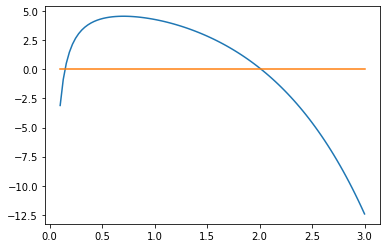

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    y = (8*x-1)/x - np.exp(x)
    return y

X = np.linspace(1.e-1, 3,100)
Y = f(X)
plt.plot(X,Y)
#X = np.linspace(-3,-1.e-1,100)
#Y = f(X)
C=np.zeros(100);
#plt.plot(X,Y)
plt.plot(X,C)

b) On considère les fonctions $g_1$ et $g_2$ définies par 
$g_1(x) = \frac{1}{8}(1+xe^x)$ et $g_2(x) = \ln\left(\frac{8x-1}{x}\right)$, respectivement. Noter que $g_2$ n'est pas définie si $0< x\leq 1/8$.

Vérifier que  les problèmes de point fixe $g_i(x) = x$ sont équivalentes à $f(x)=0$. 

Etudier la convergence de la méthode de point fixe appliquée aux fonctions $g_i$, $i=1,2$, avec $x_0=1$. Pour cela on pourra dessiner les graphes des fonctions $g_i$. 


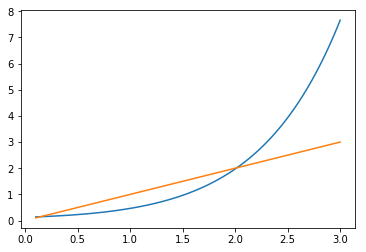

In [2]:

def g1(x):
    y = (1+x*np.exp(x))/8.0 
    return y

def g2(x):
    y = np.log((8.0*x - 1.)/x)
    return y


X = np.linspace(1.e-1, 3,100)
Y1 = g1(X)

plt.plot(X,Y1)
plt.plot(X,X)


[0.13       0.1589899  0.1879798  0.2169697  0.2459596  0.27494949
 0.30393939 0.33292929 0.36191919 0.39090909 0.41989899 0.44888889
 0.47787879 0.50686869 0.53585859 0.56484848 0.59383838 0.62282828
 0.65181818 0.68080808 0.70979798 0.73878788 0.76777778 0.79676768
 0.82575758 0.85474747 0.88373737 0.91272727 0.94171717 0.97070707
 0.99969697 1.02868687 1.05767677 1.08666667 1.11565657 1.14464646
 1.17363636 1.20262626 1.23161616 1.26060606 1.28959596 1.31858586
 1.34757576 1.37656566 1.40555556 1.43454545 1.46353535 1.49252525
 1.52151515 1.55050505 1.57949495 1.60848485 1.63747475 1.66646465
 1.69545455 1.72444444 1.75343434 1.78242424 1.81141414 1.84040404
 1.86939394 1.89838384 1.92737374 1.95636364 1.98535354 2.01434343
 2.04333333 2.07232323 2.10131313 2.13030303 2.15929293 2.18828283
 2.21727273 2.24626263 2.27525253 2.30424242 2.33323232 2.36222222
 2.39121212 2.42020202 2.44919192 2.47818182 2.50717172 2.53616162
 2.56515152 2.59414141 2.62313131 2.65212121 2.68111111 2.7101

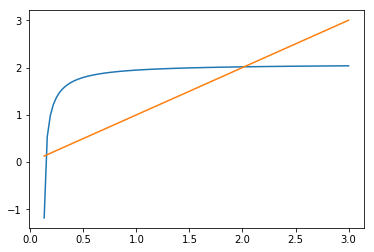

In [3]:
X2 = np.linspace(0.130, 3,100)
Y2 = g2(X2)
print(X2)
print(Y2)
print(g2(1.0))
plt.plot(X2,Y2)
plt.plot(X2,X2)

c) Calculer, avec la fonction point fixe programmée dans la partie 1, les points fixes de $g_1$ et $g_2$ en utilisant $x_0=1$ comme point initial des itérations. Expliquer les résultats observés. Serait-il possible de calculer les deux point fixes (racines de $f$) avec une seule fonction ($g_1$ ou $g_2$) ? 


In [4]:
def pointfixe(g, x0, tol, Nmax):
    err = 1. + tol #erreur initial
    k = 0
    xk = x0;
    while err > tol and k<=Nmax : 
        xp = xk     #on garde l'itéré précédent.  
        xk = g(xk)  # xk itéré suivant    
        err = abs(xk-xp)  #  calcul de l'erreur 
        k = k+1
    #fin while
    return [xk,g(xk),err,k] 
#fin pointfixe

r1 = pointfixe(g1,1.0,1e-8,100)
r2 = pointfixe(g2,1.0,1e-8,100)

print("point fixe g1 : ", r1[0], " point fixe g2 : ", r2[0])

point fixe g1 :  0.1461424479590108  point fixe g2 :  2.0154127189132667


### Exercice 2 (Algorithme de Steffenson)

Programmer l'algorithme suivant : 

1. Etant donnés : 
     - une tolérance $tol$
     - un nombre maximal d'itérations $Nmax$
     - une fonction $g$
     - un point initial $x_0$

2. $k=0$, $err = \varepsilon + 1.$ (initialisation) 

3. tant que le critère d'arrêt n'est pas verifié, faire 
    
    $\quad\quad x_{1} = g(x_{0})$
    
    $\quad\quad x_{2} = g(x_{1})$
    
    $\quad\quad x_{e} = x_{0} - \frac{(x_{1} - x_{0})^2}{(x_{2}-2 x_{1} + x_{0})}$
    
    $\quad\quad$ calculer $err = |x_e-x_0|$
    
    $\quad\quad k \leftarrow k+1$ 
    
    $\quad\quad x_0 = x_e$

$\quad$ fin (tant que)

4. Retourner $x_{e}$, $g(x_{e})$, $k$ et $err$

On doit arrêter l'algorithme si 
$|x_k - x_{k-1}|< \varepsilon $ ou $k > Nmax$. 

On pourra modifier la fonction point fixe programmé dans la partie 1. 


In [5]:
def steffenson(g, x0, tol, Nmax):
    err = 1. + tol #erreur initial
    k = 0
    while err > tol and k<=Nmax : 
        x1 = g(x0)
        x2 = g(x1)
        xe = x0 - ((x1-x0)**2)/(x2 - 2.*x1 + x0)
        err = abs(xe - x0) #à compléter
        k = k+1   #à compléter
        x0 = xe
    #fin while
    return [xe,g(xe), err, k] 
#fin steffenson 


b) On considère $g(x) = e^{-x}$. Comparer les méthodes de point fixe et de Steffenson en utilisant $x_0=1$ comme point initial et une tolérance $10^{-8}$. 

In [6]:
def g(x):
    y = np.exp(-x)
    return y


pf = pointfixe(g,1.0,1e-8,100)
st = steffenson(g,1.0,1e-8,100)

print('point fixe : ', pf)
print('steffenson : ', st)
#...

point fixe :  [0.5671432876313107, 0.5671432919855762, 7.67754038122348e-09, 33]
steffenson :  [0.5671432904097838, 0.5671432904097838, 5.4985904718307665e-11, 4]


c) Modifier la fonction précédente afin qu'elle retourne tous les itérés $x_e$ calculés. Estimer l'ordre de la méthode avec la fonction $g(x) = e^{-x}$.

In [40]:
def steffenson2(g, x0, tol, Nmax):
    err = 1. + tol #erreur initial
    k = 0
    xl =[]
    xl.append(x0)
    while err > tol and k<=Nmax : 
        x1 = g(x0)
        x2 = g(x1)
        xe = x0 - ((x1-x0)**2)/(x2 - 2.*x1 + x0)
        err = abs(xe-x0) #à compléter
        k = k+1   #à compléter
        x0 = xe
        xl.append(xe)
    #fin while
    
    return xl 
#fin steffenson2 

rexact = pointfixe(g,1.0,1e-12,100)
print(' solution <<exact>> ', rexact)
itst=steffenson2(g,1.0,1e-8,100)
err = abs(itst-rexact[0])
print('erreur ', err)
n=np.size(err)
print(n)
Q1 = err[1:n]/err[0:n-1]
print(" e_k+1/e_k ", Q1)
Q2 = err[1:n]/(err[0:n-1]**2)
print(" e_k+1/e_k^2 ", Q2)

 solution <<exact>>  [0.5671432904094655, 0.5671432904099644, 8.796297024105115e-13, 49]
erreur  [4.32856710e-01 1.50828066e-02 2.31475384e-05 5.53042057e-11
 3.18300941e-13]
5
 e_k+1/e_k  [3.48448026e-02 1.53469703e-03 2.38920462e-06 5.75545634e-03]
 e_k+1/e_k^2  [8.04996245e-02 1.01751423e-01 1.03216358e-01 1.04069054e+08]


Exercice 3. Soit $f(x) = (x-1)(x-2)^2$. Cette fonction a une racine de multiplicité 2 (r=2). 

a) Utilisez la fonction avec la méthode de Newton, programmée dans la partie 1, pour calculer une approximation de cette racine (utiliser $x_0=2.5$). Etudier l'ordre de convergence, est-ce que l'on a une convergence d'ordre 2. 



In [65]:
def f(x):
    y=(x-1)*(x-2)**2
    return y

def df(x):
    y = (x-2)**2 + 2*(x-1)*(x-2)
    return y

def newton(f, df, x0, tol, Nmax):
    # f fonction, df dérivée de f
    err = 1. #erreur initial
    k = 0
    xp = x0;  
    while err > tol and k<=Nmax : 
        xk = xp - f(xp)/df(xp)
        err = abs(xk-xp)
        xp = xk
        k=k+1
    #fin while
    return [xk,f(xk),err,k] 
#fin newton

def newton2(f, df, x0, tol, Nmax):
    # f fonction, df dérivée de f
    xk = []  # déclaration liste 
    err = 1. #erreur initial
    k = 0
    xk.append(x0)
    while err > tol and k<=Nmax : 
        xp = xk[k]
        xk.append(xp - f(xp)/df(xp))
        err = abs(xk[k+1]-xk[k])
        k=k+1         
    #fin while
    return xk 
#fin newton2
nw = newton(f,df,2.5,1e-8,100)
print(nw)

itnw = newton2(f,df,2.5,1e-8,100)

aitnw = np.array(itnw)
err = abs(aitnw-2.)
print(err)
n=np.size(err)
print(n)
Q1 = err[1:n]/err[0:n-1]
print(" e_k+1/e_k ", Q1)
Q2 = err[1:n]/(err[0:n-1]**2)
print(" e_k+1/e_k^2 ", Q2)

[2.0000000053867413, 2.9016981722891423e-17, 5.3867408311703e-09, 27]
[5.00000000e-01 2.85714286e-01 1.57142857e-01 8.35672998e-02
 4.33350534e-02 2.21083535e-02 1.11724494e-02 5.61691624e-03
 2.81627966e-03 1.41011434e-03 7.05553229e-04 3.52900934e-04
 1.76481585e-04 8.82485771e-05 4.41262352e-05 2.20636044e-05
 1.10319239e-05 5.51599236e-06 2.75800379e-06 1.37900380e-06
 6.89502373e-07 3.44751306e-07 1.72375683e-07 8.61878489e-08
 4.30939262e-08 2.15469638e-08 1.07734821e-08 5.38674128e-09]
28
 e_k+1/e_k  [0.57142857 0.55       0.53179191 0.51856472 0.51017252 0.50534968
 0.50274708 0.5013925  0.50070111 0.50035178 0.5001762  0.50008818
 0.50004411 0.50002206 0.50001103 0.50000552 0.50000276 0.50000138
 0.50000069 0.50000034 0.50000017 0.50000009 0.50000004 0.50000002
 0.50000002 0.50000001 0.50000002]
 e_k+1/e_k^2  [1.14285714e+00 1.92500000e+00 3.38413032e+00 6.20535450e+00
 1.17727448e+01 2.28578614e+01 4.49988233e+01 8.92647274e+01
 1.77788135e+02 3.54830646e+02 7.08913490e+02 1.

b) Programmer une fonction avec la modification suivante de la méthode de Newton adaptée au calcul des racines de multiplicité $m$ : 

1. Etant données $f$ et $f'$ (la fonction et sa dérivée), $x_0$ (le point initial), $\varepsilon$ (une tolérance), 
$Nmax$ (le nombre maximal d'itérations), $m$ la multiplicité de la racine à calculer

2. $k=0$, $err=1 + \varepsilon$  (initialisation).

3. tant que le critère d'arrêt n'est pas verifié, faire

$\quad\quad x_{k+1} = x_k - m \displaystyle\frac{f(x_k)}{f'(x_k)}$.

$\quad\quad$Calculer $err$ 

$\quad\quad k \leftarrow k+1$ 

fin (tant que)

4. Retourner $x_k$, $f(x_k)$, $k$ et $err$

On doit arrêter l'algorithme si 
$|x_k - x_{k-1}|< \varepsilon $ ou $k > Nmax$. 


In [55]:
def newtonmult(f, df, x0, tol, Nmax,m):
    # f : fonction, df : dérivée de f, tol : tolérance, Nmax : nombre max d'itérations  m : multiplicité
    err = 1. #erreur initial
    k = 0
    xp = x0;  # valeur itéré précédent (xp corréspond à x_k)
    while err > tol and k<=Nmax : 
        xk = xp - m*f(xp)/df(xp)
        err = abs(xk-xp)
        xp = xk
        k=k+1
      #fin while
    return [xk,f(xk),err,k]  
#fin newtonmult2






c) Etudier l'ordre de convergence de cette méthode. Pour cela, utiliser la fonction $f(x) = (x-1)*(x-2)^2$ et le point initial $x_0 = 2.5$ et $m=2$. (Modifier la fonction pour qu'elle retourne tous les itérés $x_k$ calculés). Est-ce que la méthode serait d'ordre 2 ?


In [57]:
nwm = newtonmult(f,df,2.5,1e-8,100,2)
print(nwm)



[2.0, 0.0, 3.4989788844086434e-12, 5]


In [68]:
def newtonmult2(f, df, x0, tol, Nmax,m):
    # f : fonction, df : dérivée de f, tol : tolérance, Nmax : nombre max d'itérations  m : multiplicité
    err = 1. #erreur initial
    k = 0
    xp = x0;  # valeur itéré précédent (xp corréspond à x_k)
    xl =[x0]
    while err > tol and k<=Nmax : 
        xk = xp - m*f(xp)/df(xp)
        err = abs(xk-xp)
        xp = xk
        k=k+1
        xl.append(xp)
      #fin while
    return xl #[xk,f(xk),err,k]  
#fin newtonmult

itnwm = newtonmult2(f,df,2.5,1e-8,100,2)

aitnwm = np.array(itnwm)
err = abs(aitnwm-2.)
print(err)
n=np.size(err)
print(n)
Q1 = err[1:n]/err[0:n-1]
print(" e_k+1/e_k ", Q1)
Q2 = err[1:n]/(err[0:n-1]**2)
print(" e_k+1/e_k^2 ", Q2)

[5.00000000e-01 7.14285714e-02 2.30414747e-03 2.64540467e-06
 3.49897888e-12 0.00000000e+00]
6
 e_k+1/e_k  [1.42857143e-01 3.22580645e-02 1.14810563e-03 1.32266300e-06
 0.00000000e+00]
 e_k+1/e_k^2  [0.28571429 0.4516129  0.49827784 0.49998513 0.        ]
